# ai_videogames · Reto evaluable PRO
## Transfer Learning para criaturas RPG

### Objetivo
Construir un clasificador de criaturas inspirado en RPG usando **Oxford-IIIT Pet** y una arquitectura preentrenada.

### Metas orientativas
- **Accuracy ≥ 0.80** en fase 1
- **Accuracy ≥ 0.85** tras fine-tuning

> No son obligatorias si tu análisis es bueno, pero sirven como referencia.


In [20]:
%tensorflow_version 2.x
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 160
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]"],
    with_info=True,
    as_supervised=True
)

label_names = ds_info.features["label"].names
num_classes = ds_info.features["label"].num_classes
print("Clases:", num_classes)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
Clases: 37


## 1) Preprocesado
Completa el pipeline de datos y documenta brevemente qué hace cada paso.

### Documentación del Preprocesado:

*   **`preprocess_input`**: Esta función prepara los datos de imagen para la MobileNetV2 escalando los valores de los píxeles a un rango de `[-1, 1]`. Es crucial para que el modelo preentrenado funcione correctamente, ya que fue entrenado con este rango de entrada.

*   **`preprocess` función**: Esta función toma una imagen y su etiqueta. Primero, redimensiona la imagen a `(IMG_SIZE, IMG_SIZE)` para asegurar un tamaño consistente. Luego, aplica la función `preprocess_input` a la imagen redimensionada para normalizar sus valores de píxeles.

### Pasos del pipeline de datos (`tf.data`):

*   **`.shuffle(2000, seed=SEED)`**: Aleatoriza el orden de los elementos en el conjunto de datos. Esto ayuda a prevenir el sobreajuste y asegura que el modelo no aprenda el orden de las muestras, mejorando la generalización.

*   **`.map(preprocess, num_parallel_calls=AUTOTUNE)`**: Aplica la función `preprocess` a cada elemento (imagen y etiqueta) del conjunto de datos. `num_parallel_calls=AUTOTUNE` permite que la transformación se ejecute en paralelo, lo que acelera el procesamiento de datos.

*   **`.batch(BATCH_SIZE)`**: Agrupa elementos contiguos del conjunto de datos en lotes. Entrenar el modelo con lotes de datos en lugar de muestras individuales es computacionalmente más eficiente y ayuda a estabilizar el proceso de entrenamiento.

*   **`.prefetch(AUTOTUNE)`**: Superpone el preprocesamiento de datos y la ejecución del modelo. Mientras el modelo está entrenando con un lote de datos, el siguiente lote se está preprocesando en segundo plano, lo que reduce el tiempo de inactividad de la CPU/GPU y mejora la eficiencia del pipeline.

In [21]:
# TODO: elige preprocess_input según tu arquitectura
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(tf.cast(image, tf.float32))
    return image, label

train_ds = (
    ds_train_raw
    .shuffle(2000, seed=SEED)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    ds_test_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

## 2) Data augmentation
Añade al menos 2 transformaciones y justifícalas en una celda markdown.


In [22]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

## 3) Fase 1 · Feature extraction
Usa una base preentrenada y congélala.
Sugerencias:
- MobileNetV2
- EfficientNetB0
- ResNet50


In [23]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True
    )
]

history_1 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 108s 990ms/step - accuracy: 0.5503 - loss: 1.6949 - val_accuracy: 0.8302 - val_loss: 0.6517
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 91s 939ms/step - accuracy: 0.8424 - loss: 0.5514 - val_accuracy: 0.8424 - val_loss: 0.5040
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 146s 982ms/step - accuracy: 0.8838 - loss: 0.3875 - val_accuracy: 0.8587 - val_loss: 0.4672
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 95s 966ms/step - accuracy: 0.9062 - loss: 0.3131 - val_accuracy: 0.8736 - val_loss: 0.4225
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 140s 949ms/step - accuracy: 0.9273 - loss: 0.2567 - val_accuracy: 0.8736 - val_loss: 0.4116


## 4) Fase 2 · Fine-tuning
Desbloquea parcialmente la base y vuelve a entrenar con learning rate más bajo.


In [6]:
base_model.trainable = True

# TODO: puedes experimentar con este corte
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=8,
    initial_epoch=history_1.epoch[-1] + 1,
    callbacks=callbacks
)

Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.7660 - loss: 0.7528 - val_accuracy: 0.8750 - val_loss: 0.4074
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.8244 - loss: 0.5622 - val_accuracy: 0.8791 - val_loss: 0.4054


## 5) Curvas de entrenamiento
Representa:
- accuracy train
- accuracy validación
- marca el punto donde empieza el fine-tuning


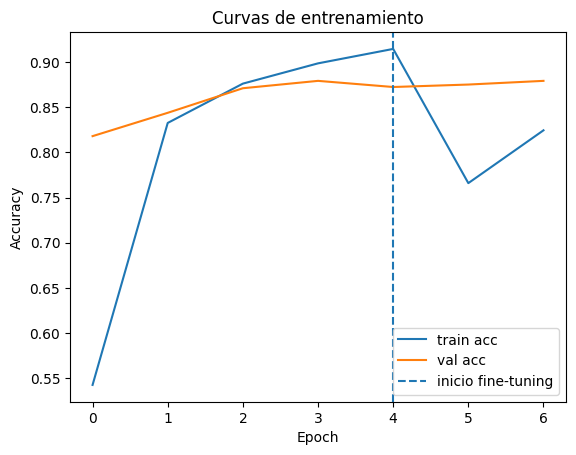

In [7]:
acc = history_1.history["accuracy"] + history_2.history["accuracy"]
val_acc = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]

plt.figure()
plt.plot(acc, label="train acc")
plt.plot(val_acc, label="val acc")
plt.axvline(x=len(history_1.history["accuracy"])-1, linestyle="--", label="inicio fine-tuning")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Curvas de entrenamiento")
plt.show()

## 6) Evaluación cuantitativa
Reporta accuracy final y compárala con tus objetivos.


In [8]:
loss, acc = model.evaluate(test_ds, verbose=0)
print("Accuracy final:", acc)

Accuracy final: 0.875


## 7) Evaluación cualitativa
Muestra:
- 12 ejemplos correctamente clasificados
- 12 errores
- análisis breve de qué tipo de confusiones observas


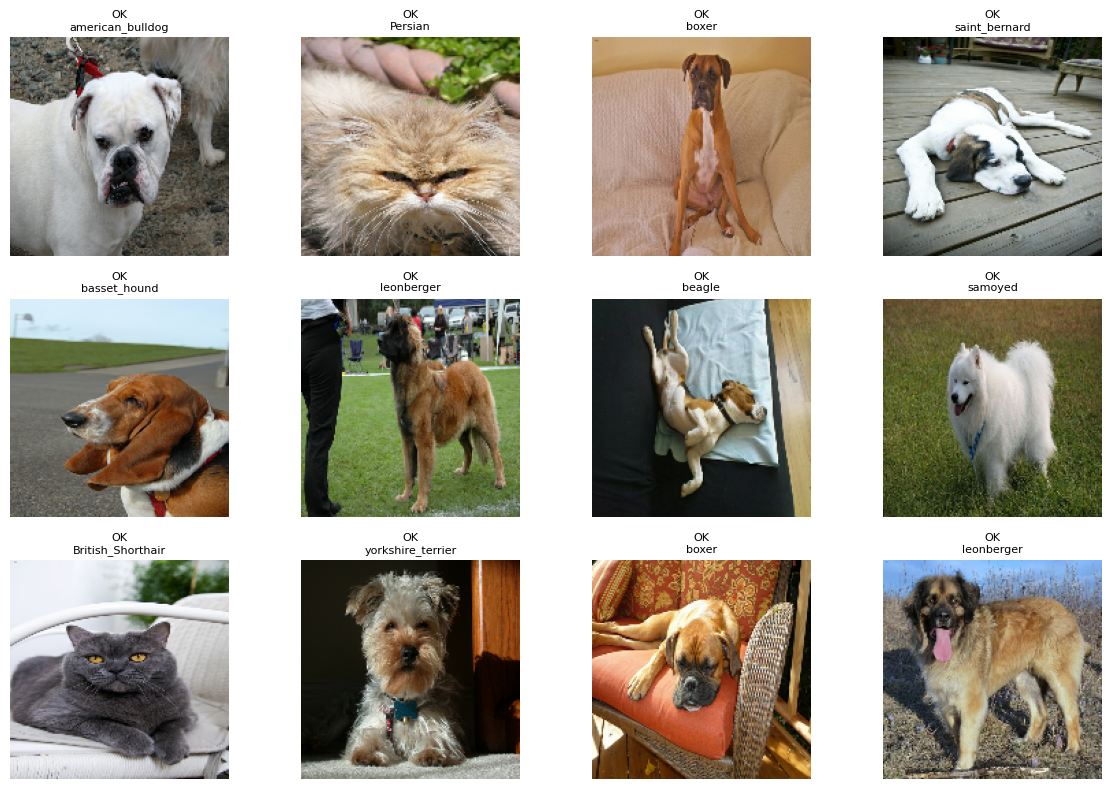

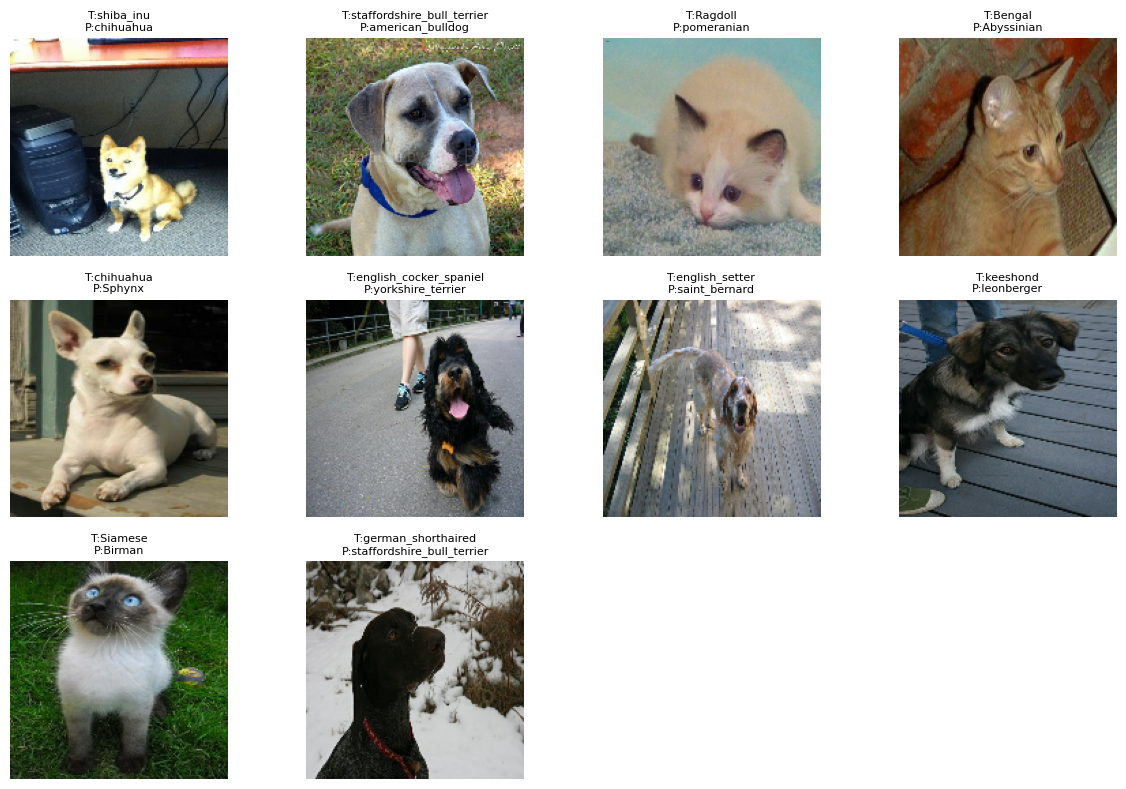

In [9]:
sample_images = []
sample_labels = []

for images, labels in test_ds.take(3):
    sample_images.append(images)
    sample_labels.append(labels)

sample_images = tf.concat(sample_images, axis=0)
sample_labels = tf.concat(sample_labels, axis=0)

preds = model.predict(sample_images, verbose=0)
pred_classes = np.argmax(preds, axis=1)

correct = np.where(pred_classes == sample_labels.numpy())[0]
wrong = np.where(pred_classes != sample_labels.numpy())[0]

plt.figure(figsize=(12,8))
for i, idx in enumerate(correct[:12]):
    plt.subplot(3,4,i+1)
    img = (sample_images[idx].numpy() + 1.0) / 2.0
    plt.imshow(np.clip(img,0,1))
    plt.title(f"OK\n{label_names[int(pred_classes[idx])]}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
for i, idx in enumerate(wrong[:12]):
    plt.subplot(3,4,i+1)
    img = (sample_images[idx].numpy() + 1.0) / 2.0
    plt.imshow(np.clip(img,0,1))
    t = label_names[int(sample_labels[idx])]
    p = label_names[int(pred_classes[idx])]
    plt.title(f"T:{t}\nP:{p}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 8) Matriz de confusión (bonus recomendable)


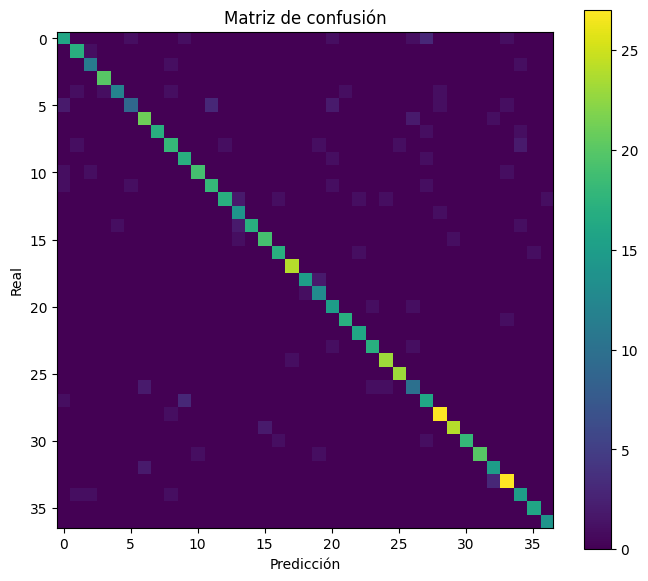

In [10]:
all_preds = []
all_true = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    all_preds.append(np.argmax(preds, axis=1))
    all_true.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

cm = tf.math.confusion_matrix(all_true, all_preds, num_classes=num_classes).numpy()

plt.figure(figsize=(8,7))
plt.imshow(cm)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.colorbar()
plt.show()

## 9) Guardar modelo
Usa un nombre que incluya tu equipo o usuario.


In [11]:
model.save("semana3_pro_equipoXX_transfer_learning.keras")

## 10) Reflexión final (obligatoria)

### Respuestas:

El Transfer Learning ofreció una ventaja significativa al permitirnos aprovechar el conocimiento preexistente de modelos entrenados en grandes conjuntos de datos, como ImageNet. Esto nos ahorró un enorme tiempo de entrenamiento y recursos computacionales que serían necesarios para entrenar un modelo desde cero con un dataset relativamente pequeño como Oxford-IIIT Pet. Además, facilitó alcanzar una buena precisión en menos épocas.

La diferencia clave observada entre *feature extraction* y *fine-tuning* radica en la flexibilidad. En *feature extraction*, la base del modelo preentrenado se congela, usando solo sus capas convolucionales para extraer características genéricas, lo que es rápido y eficaz para aprender patrones de alto nivel. Durante el *fine-tuning*, se desbloquean algunas capas de la base del modelo y se reentrenan con una tasa de aprendizaje muy baja. Esto permite al modelo adaptar esas características más específicas a nuestro conjunto de datos particular, mejorando el rendimiento y la especialización.

Si aplicamos este modelo a sprites, enemigos o criaturas de un videojuego real, las limitaciones serían varias. Primero, los datos de entrenamiento (imágenes de mascotas reales) son muy diferentes en estilo, iluminación y representación a los gráficos de videojuegos, que suelen ser estilizados o renderizados. Esto podría llevar a una baja capacidad de generalización. Segundo, la variabilidad de poses, animaciones y perspectivas en un videojuego es mucho mayor que en imágenes estáticas, y el modelo actual no está optimizado para esas dinámicas. Tercero, el tamaño y la resolución de los sprites suelen ser menores, lo que podría requerir adaptaciones específicas en el preprocesado y la arquitectura.

Para una Semana 4, adaptaría este enfoque a personajes 2D realizando las siguientes acciones: recopilaría un dataset específico de sprites 2D con diversas animaciones y perspectivas. Posteriormente, realizaría un preprocesado que incluyera técnicas de aumento de datos adaptadas a sprites, como rotaciones, escalados y cambios de color o transparencia. Finalmente, exploraría arquitecturas más ligeras o modelos preentrenados en dominios visuales más cercanos a los gráficos de videojuegos si estuvieran disponibles, o ajustaría las capas convolucionales para que aprendan características más relevantes para el estilo artístico de los sprites.